# **1. Project Overview :**
In this project, we build a student analytics system that computes useful statistics such as average grades, participation levels, and success rates, while preserving the privacy of individual students.

In many educational settings, sharing statistics about student performance is important for evaluation and decision-making. However, directly publishing such data can risk exposing sensitive information about individuals.

To address this, we integrate **differential privacy** techniques into the analysis. Instead of releasing exact statistics, we add carefully calibrated noise so that the results remain useful, but no single student's data can be inferred.

The project combines:

- Data analysis and visualization
- Differential privacy mechanisms (Laplace and Gaussian)
- Evaluation of privacy vs accuracy trade offs

# **2. Problem Statment :**
Educational data is inherently sensitive. A student’s grades, participation, and performance should not be exposed or identifiable in published reports.

Even when only aggregated statistics are shared (like averages), there is still a risk. For example, if someone knows most of the dataset, they could potentially infer the missing individual's data by comparing results.

This leads to the core question of our project:

- How can we share useful statistics about students without compromising their privacy?

Our goal is to design a system that:

- Provides meaningful insights about student performance
- Prevents the identification of any individual student
- Maintains a balance between data utility and privacy protection

# **3. Introduction to Differential Privacy :**
Differential privacy is a mathematical framework designed to protect individual data while still allowing useful analysis.

The key idea is simple:

   - The output of an analysis should not change significantly whether or not a single individual’s data is included.

In practice, this is achieved by adding controlled random noise to the results.

A central concept in differential privacy is the parameter ε (epsilon):

- A small ε means strong privacy but more noise (less accuracy)
- A large ε means better accuracy but weaker privacy

This creates a trade-off:

- We want results that are still useful
- But we also want to guarantee that no individual can be identified

In this project, we implement two common mechanisms:

- Laplace mechanism (for strict privacy guarantees)
- Gaussian mechanism (for approximate privacy)

We then study how these mechanisms affect the accuracy of the results.

# **4. Dataset Description :**
The dataset used in this project contains student performance records with multiple evaluation components.

**Data Source :**

This dataset is based on marks from Introduction to artificial intelligence module 2024/2025, provided from a previous academic year.

The data has been used here for analysis purposes in a privacy-preserving context.

**Dataset Characteristics :**

- Number of students: 260
- Each row represents one student
- Each column represents a component of evaluation

 **Features included:**
- ID
- Quiz 1, Quiz 2, Quiz 3
- Participation Tutorials
- Participation Labs
- Participation Average
- Project mark
- Midterm mark
- Semester Work
- Final mark
- Course mark

These features allow us to analyze different aspects of student performance, from continuous assessment to final evaluation.

The dataset is well suited for this project because:

- It contains multiple numerical attributes
- It reflects realistic grading scenarios
- It allows testing differential privacy on different types of statistics

In the next sections, we will load and explore this dataset before applying privacy preserving techniques.

# **5. Importing Libraries :**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
np.random.seed(42)

# **6. Data Loading and Preprocessing :**

We start by loading the dataset and inspecting its structure.

This includes:

* Previewing the first rows
* Checking dataset shape (number of rows and columns)
* Understanding column names and data types




In [2]:
# Load dataset
df = pd.read_csv("students.csv")

# Preview data
print("First 5 rows:")
display(df.head())

# Shape
print("\nDataset shape:", df.shape)

# Columns
print("\nColumns:")
print(df.columns.tolist())

# Data types and missing values
print("\nDataset info:")
df.info()
# Summary statistics
df.describe()

First 5 rows:


,ID,Quiz 1,Quiz 2,Quiz 3,Participation Tutorials,Participation Labs,Project mark,Midterm mark,Final mark,Participation Avg,Semester Work,Course mark
0,1,13.49,9.22,6.99,14.44,18.21,11.00,11.94,12.61,16.33,10.17,11.50
1,2,11.59,11.82,13.63,10.66,12.85,15.98,9.76,13.23,11.76,13.25,12.55
2,3,13.94,2.28,10.01,14.95,16.70,12.48,4.73,12.33,15.82,9.68,9.75
3,4,16.57,8.93,13.71,15.53,13.90,10.73,9.65,8.05,14.72,9.49,8.74
4,5,11.30,11.24,9.71,15.40,13.57,14.61,14.21,13.51,14.48,11.71,12.93



Dataset shape: (260, 12)

Columns:
['ID', 'Quiz 1', 'Quiz 2', 'Quiz 3', 'Participation Tutorials', 'Participation Labs', 'Project mark', 'Midterm mark', 'Final mark', 'Participation Avg', 'Semester Work', 'Course mark']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       260 non-null    int64  
 1   Quiz 1                   260 non-null    float64
 2   Quiz 2                   260 non-null    float64
 3   Quiz 3                   260 non-null    float64
 4   Participation Tutorials  260 non-null    float64
 5   Participation Labs       260 non-null    float64
 6   Project mark             260 non-null    float64
 7   Midterm mark             260 non-null    float64
 8   Final mark               260 non-null    float64
 9   Participation Avg        260 non-null    float64
 10  Semest

,ID,Quiz 1,Quiz 2,Quiz 3,Participation Tutorials,Participation Labs,Project mark,Midterm mark,Final mark,Participation Avg,Semester Work,Course mark
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.00000,260.000000,259.000000
mean,130.500000,12.008538,11.991615,11.892577,14.367846,14.187769,13.386000,11.907692,12.734692,14.25300,12.148808,12.351197
std,75.199734,2.874754,2.918739,3.047601,2.348373,2.568423,2.856288,2.955623,2.872765,1.69205,1.571812,1.765871
min,1.000000,4.140000,2.280000,3.910000,7.940000,6.760000,5.230000,3.240000,3.940000,9.14000,7.640000,7.500000
25%,65.750000,9.942500,9.885000,9.882500,12.705000,12.395000,11.332500,9.862500,10.985000,13.06750,11.105000,11.315000
50%,130.500000,12.185000,11.950000,11.895000,14.475000,14.200000,13.135000,11.855000,12.715000,14.31500,12.140000,12.460000
75%,195.250000,13.885000,13.902500,13.877500,15.770000,15.847500,15.237500,13.927500,14.672500,15.53500,13.440000,13.575000
max,260.000000,20.000000,20.000000,19.900000,20.000000,20.000000,20.000000,20.000000,19.690000,18.34000,16.120000,16.700000


## **Data Preprocessing :**

Before performing any analysis, we will clean and prepare the dataset by following these steps :


1. Standardize column names (lowercase , no spaces)
2. Create additional features:

   * `quiz_avg`: average of the three quizzes
   * `passed`: indicates whether a student passed the module



### Defining the Pass Condition

we define passing like this :

> A student is considered to have passed if their **course mark ≥ 10/20**


###  Why we create the `passed` feature :

We introduce a binary variable **passed** derived from the course mark using a threshold .

This is mainly to enable a **pass rate query**, which is a classic case in differential privacy.

Without it, the analysis would only cover averages and means (continuous queries) which is limited.

Including **passed** allows us to evaluate differential privacy on **proportion based queries**, which typically have lower sensitivity and are commonly used in real educational reports.

This helps us compare how differential privacy affects:

  - Continuous data (grades)
  - Binary data (pass/fail)


In [3]:
# Standardize column names
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Create quiz average
df["quiz_avg"] = df[["quiz_1", "quiz_2", "quiz_3"]].mean(axis=1)

# Compute dynamic pass threshold
course_avg = df["course_mark"].mean()
PASS_THRESH = 10

print(f"Average course mark: {course_avg:.2f}")
print(f"pass threshold : {PASS_THRESH:.2f}")

# Create passed column
df["passed"] = (df["course_mark"] >= PASS_THRESH).astype(int)

# Preview updated dataset
df.head()

Average course mark: 12.35
pass threshold : 10.00


,id,quiz_1,quiz_2,quiz_3,participation_tutorials,participation_labs,project_mark,midterm_mark,final_mark,participation_avg,semester_work,course_mark,quiz_avg,passed
0,1,13.49,9.22,6.99,14.44,18.21,11.00,11.94,12.61,16.33,10.17,11.50,9.900000,1
1,2,11.59,11.82,13.63,10.66,12.85,15.98,9.76,13.23,11.76,13.25,12.55,12.346667,1
2,3,13.94,2.28,10.01,14.95,16.70,12.48,4.73,12.33,15.82,9.68,9.75,8.743333,0
3,4,16.57,8.93,13.71,15.53,13.90,10.73,9.65,8.05,14.72,9.49,8.74,13.070000,0
4,5,11.30,11.24,9.71,15.40,13.57,14.61,14.21,13.51,14.48,11.71,12.93,10.750000,1


# **7. Dataset Profiling :**
In this section, we extract key characteristics of the dataset automatically.

This helps us:

- Understand the scale and distribution of the data
- Compute values needed later for differential privacy (like ranges and sensitivities)

We will compute:
- Number of students
- Range of important features
- Basic statistics
- Pass threshold and pass rate

In [4]:
N = len(df)
FINAL_MIN = float(df["final_mark"].min())
FINAL_MAX = float(df["final_mark"].max())
FINAL_RNG = FINAL_MAX - FINAL_MIN

PART_MIN = float(df["participation_avg"].min())
PART_MAX = float(df["participation_avg"].max())
PART_RNG = PART_MAX - PART_MIN

QUIZ_MIN = float(df["quiz_avg"].min())
QUIZ_MAX = float(df["quiz_avg"].max())
QUIZ_RNG = QUIZ_MAX - QUIZ_MIN

# Pass rate
PASS_RATE = df["passed"].mean()

# Display nicely
print("         Auto Derived Dataset Profile       ")
print(f" Students (N)            : {N:>14}   ")
print(f" Final mark range        : [{FINAL_MIN:5.2f}, {FINAL_MAX:5.2f}]   ")
print(f" Participation range     : [{PART_MIN:5.2f}, {PART_MAX:5.2f}]   ")
print(f" Quiz average range      : [{QUIZ_MIN:5.2f}, {QUIZ_MAX:5.2f}]   ")
print(f" Pass threshold          : {PASS_THRESH:>14.2f}   ")
print(f" Pass rate               : {PASS_RATE:>14.2%}   ")


         Auto Derived Dataset Profile       
 Students (N)            :            260   
 Final mark range        : [ 3.94, 19.69]   
 Participation range     : [ 9.14, 18.34]   
 Quiz average range      : [ 7.90, 15.85]   
 Pass threshold          :          10.00   
 Pass rate               :         88.46%   


# **8. Exploratory Data Analysis :**
Before applying any privacy mechanism, we explore the dataset to understand its structure and patterns.

The goal here is simple:

 - Get a clear idea of how the data behaves before adding noise

We focus on:

- Distributions of variables
- Spread and outliers
- Relationships between features

This step helps ensure that later comparisons (original vs private) are meaningful.

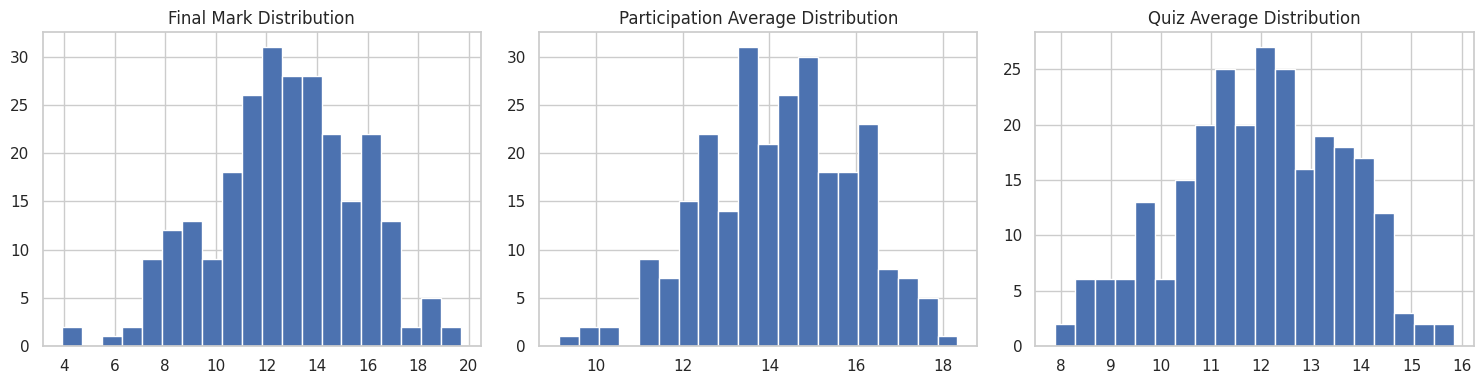

In [5]:
# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["final_mark"].hist(bins=20, ax=axes[0])
axes[0].set_title("Final Mark Distribution")

df["participation_avg"].hist(bins=20, ax=axes[1])
axes[1].set_title("Participation Average Distribution")

df["quiz_avg"].hist(bins=20, ax=axes[2])
axes[2].set_title("Quiz Average Distribution")

plt.tight_layout()
plt.show()

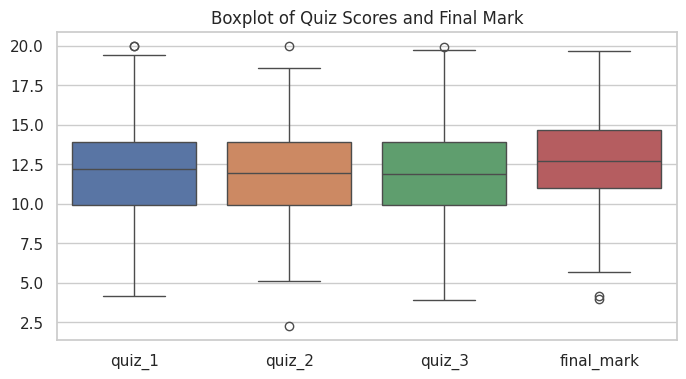

In [6]:
# Boxplots
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[["quiz_1", "quiz_2", "quiz_3", "final_mark"]])
plt.title("Boxplot of Quiz Scores and Final Mark")
plt.show()

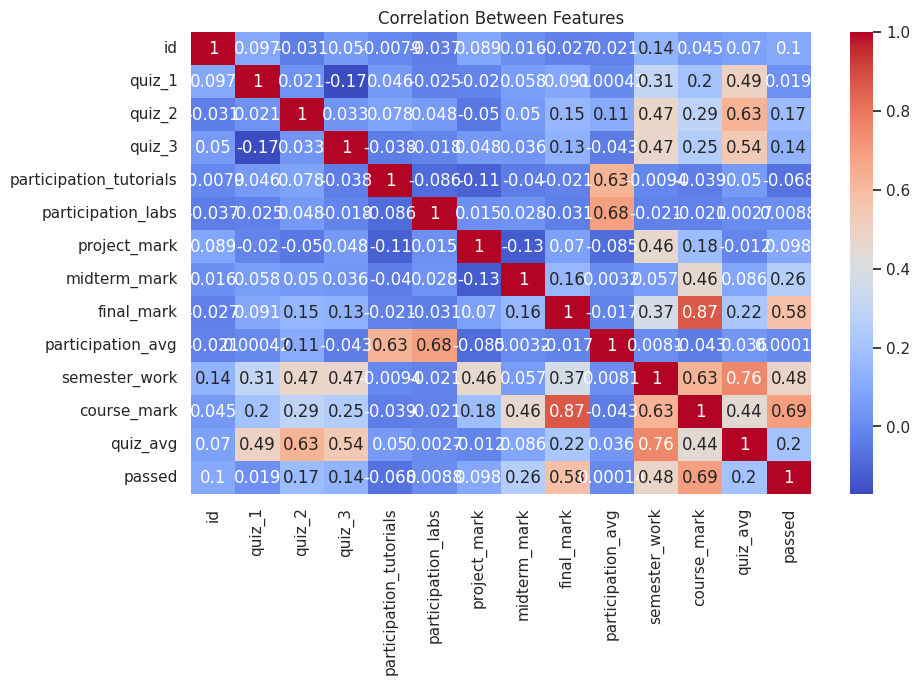

In [7]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Features")
plt.show()

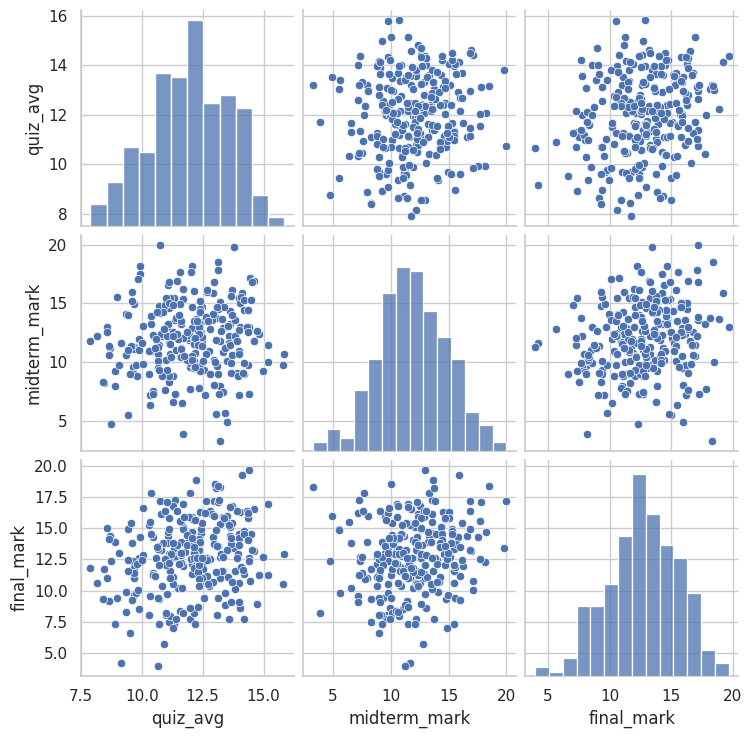

In [8]:
# Pairplot to see the relationships
sns.pairplot(df[["quiz_avg", "midterm_mark", "final_mark"]])
plt.show()

# **10. Privacy Risk Demonstration :**
Before applying differential privacy, we demonstrate why do we need it .

Even simple statistics like the average can slightly change when a single student is removed from the dataset.

This may seem small, but in certain cases it can be enough to infer information about individuals.

The goal here is to show that **Aggregated data is not automatically private**.



In [9]:
# Original mean
original_mean = df["final_mark"].mean()

# Remove one student
df_removed = df.iloc[:-1]
removed_mean = df_removed["final_mark"].mean()

# Difference
difference = abs(original_mean - removed_mean)

print("Original mean:", round(original_mean, 4))
print("After removing one student:", round(removed_mean, 4))
print("Difference:", round(difference, 6))

Original mean: 12.7347
After removing one student: 12.7389
Difference: 0.004188


# **11. True Non Private Statistics :**
In this section, we compute the exact statistics from the dataset.

These values represent the true results without any privacy protection.

They will serve as a reference to:

- Compare against differentially private outputs
- Measure the error introduced by noise

In [10]:
def true_mean_final(data):
    return float(data["final_mark"].mean())

def true_mean_participation(data):
    return float(data["participation_avg"].mean())

def true_mean_quiz(data):
    return float(data["quiz_avg"].mean())

def true_count(data):
    return float(len(data))

def true_pass_rate(data):
    return float(data["passed"].mean())

In [11]:
TRUE_STATS = {
    "mean_final_mark": true_mean_final(df),
    "mean_participation": true_mean_participation(df),
    "mean_quiz_avg": true_mean_quiz(df),
    "count": true_count(df),
    "pass_rate": true_pass_rate(df),
}

print("   True Statistics  ")

for name, val in TRUE_STATS.items():
    print(f"  {name:<22} : {val:>10.4f}  ")


   True Statistics  
  mean_final_mark        :    12.7347  
  mean_participation     :    14.2530  
  mean_quiz_avg          :    11.9642  
  count                  :   260.0000  
  pass_rate              :     0.8846  


# **12. Sensitivity Analysis**

In differential privacy, **sensitivity** measures how much a query’s output can change when a single individual is added or removed from the dataset.

 It is defined as:

$$
\Delta f = \max_{D, D'} \left| f(D) - f(D') \right|
$$

Where:

- $D$ and $D'$ are two datasets differing by **one record**
- $f$ is the query function


Sensitivity directly controls the **amount of noise** we need to add :

- High sensitivity → output can change a lot → need **more noise**
- Low sensitivity → output is stable → need **less noise**

This is why some statistics (like averages) are noisier than others (like proportions).


We compute sensitivity based on **observed dataset ranges**.

### 1. Count

$$
\Delta = 1
$$

### 2. Mean (general form) : continuoues values like : marks ..

$$
\Delta = \frac{\text{max} - \text{min}}{n}
$$

### 3. Pass rate (binary mean)

$$
\Delta = \frac{1}{n}
$$


In [12]:
def sensitivity_count():
    return 1.0


def sensitivity_mean(n, value_range):
    return value_range / n


def sensitivity_pass_rate(n):
    return 1.0 / n

In [13]:
N = len(df)

FINAL_RANGE = df["final_mark"].max() - df["final_mark"].min()
PART_RANGE  = df["participation_avg"].max() - df["participation_avg"].min()
QUIZ_RANGE  = df["quiz_avg"].max() - df["quiz_avg"].min()

SENSITIVITIES = {
    "count": sensitivity_count(),
    "mean_final_mark": sensitivity_mean(N, FINAL_RANGE),
    "mean_participation": sensitivity_mean(N, PART_RANGE),
    "mean_quiz_avg": sensitivity_mean(N, QUIZ_RANGE),
    "pass_rate": sensitivity_pass_rate(N),
}

print("Sensitivity values:")
for k, v in SENSITIVITIES.items():
    print(f"  Δ {k:<22} = {v:.8f}")

Sensitivity values:
  Δ count                  = 1.00000000
  Δ mean_final_mark        = 0.06057692
  Δ mean_participation     = 0.03538462
  Δ mean_quiz_avg          = 0.03057692
  Δ pass_rate              = 0.00384615


# **13. Differential Privacy Mechanisms :**
To achieve differential privacy, we do not release exact values.  
Instead, we add carefully calibrated **random noise**.


### 1. Laplace Mechanism (ε-DP)

The Laplace mechanism adds noise drawn from a Laplace distribution:

$$
\text{Noise} \sim \text{Laplace}\left(0, \frac{\Delta f}{\epsilon}\right)
$$

$$
f(D)_{\text{private}} = f(D) + \text{Noise}
$$

$$
f(D)_{\text{private}} = f(D) +  \text{Lap}\left(\frac{\Delta f}{\varepsilon}\right)$$

- $\Delta f$: sensitivity  
- $\epsilon$: privacy budget  

 Interpretation:

- Small $\epsilon$ → more noise → stronger privacy  
- Large $\epsilon$ → less noise → better accuracy  



### 2. Gaussian Mechanism ((ε, δ)-DP)

The Gaussian mechanism adds noise from a normal distribution:

$$
\text{Noise} \sim \mathcal{N}(0, \sigma^2)
$$

$$
\sigma = \frac{\Delta f \cdot \sqrt{2 \ln(1.25/\delta)}}{\epsilon}
$$

$$
f(D)_{\text{private}} = f(D) + \text{Noise}
$$

$$
f(D)_{\text{private}} = f(D) + \mathcal{N}\left(0,\, \frac{2\ln(1.25/\delta) \cdot (\Delta f)^2}{\varepsilon^2}\right)$$

- Used when allowing a small probability $\delta$ of failure  

We used both Laplace and Gaussian mechanisms to balance privacy and accuracy. Laplace gives strong, strict privacy for simple results like counts, while Gaussian adds smoother noise that works better for averages and trends. Using both helps us protect students’ data while still keeping the results useful .




In [14]:
def laplace_mechanism(value, sensitivity, epsilon):
    if epsilon <= 0:
        raise ValueError("epsilon must be > 0")
    scale = sensitivity / epsilon
    noise = np.random.laplace(0, scale)
    return value + noise

In [15]:
def gaussian_mechanism(value, sensitivity, epsilon, delta=1e-5):
    if epsilon <= 0 or delta <= 0:
        raise ValueError("epsilon and delta must be > 0")
    sigma = np.sqrt(2 * np.log(1.25 / delta)) * sensitivity / epsilon
    noise = np.random.normal(0, sigma)
    return value + noise

# **14. Applying Differential Privacy to Queries :**

We now combine:

- True statistics  
- Sensitivity  
- DP mechanisms  

to produce **private versions of each query** , where each function :

1. Computes the true value  
2. Computes sensitivity  
3. Adds noise using a chosen mechanism  


In [16]:
def apply_dp(true_val, sensitivity, epsilon, mechanism="laplace"):
    if mechanism == "laplace":
        return laplace_mechanism(true_val, sensitivity, epsilon)
    elif mechanism == "gaussian":
        return gaussian_mechanism(true_val, sensitivity, epsilon)
    else:
        raise ValueError("Unknown mechanism")

In [17]:
def noisy_mean_final(data, epsilon, mechanism="laplace"):
    val = data["final_mark"].mean()
    sens = sensitivity_mean(len(data), data["final_mark"].max() - data["final_mark"].min())
    return apply_dp(val, sens, epsilon, mechanism)


def noisy_mean_participation(data, epsilon, mechanism="laplace"):
    val = data["participation_avg"].mean()
    sens = sensitivity_mean(len(data), data["participation_avg"].max() - data["participation_avg"].min())
    return apply_dp(val, sens, epsilon, mechanism)


def noisy_mean_quiz(data, epsilon, mechanism="gaussian"):
    val = data["quiz_avg"].mean()
    sens = sensitivity_mean(len(data), data["quiz_avg"].max() - data["quiz_avg"].min())
    return apply_dp(val, sens, epsilon, mechanism)


def noisy_count(data, epsilon, mechanism="laplace"):
    val = len(data)
    sens = sensitivity_count()
    return apply_dp(val, sens, epsilon, mechanism)


def noisy_pass_rate(data, epsilon, mechanism="laplace"):
    val = data["passed"].mean()
    sens = sensitivity_pass_rate(len(data))
    return apply_dp(val, sens, epsilon, mechanism)

In [18]:
QUERY_FUNCTIONS = {
    "mean_final_mark": noisy_mean_final,
    "mean_participation": noisy_mean_participation,
    "mean_quiz_avg": noisy_mean_quiz,
    "count": noisy_count,
    "pass_rate": noisy_pass_rate,
}

In [19]:
epsilon_demo = 0.32

print(f"Demo with ε = {epsilon_demo}\n")

for name, func in QUERY_FUNCTIONS.items():
    true_val = TRUE_STATS[name]
    noisy_val = func(df, epsilon_demo)

    print(f"{name:<22}  true={true_val:8.4f}   noisy={noisy_val:8.4f}   error={abs(noisy_val-true_val):.4f}")

Demo with ε = 0.32

mean_final_mark         true= 12.7347   noisy= 12.6800   error=0.0547
mean_participation      true= 14.2530   noisy= 14.5092   error=0.2562
mean_quiz_avg           true= 11.9642   noisy= 12.2641   error=0.2998
count                   true=260.0000   noisy=256.3605   error=3.6395
pass_rate               true=  0.8846   noisy=  0.8706   error=0.0140


## **15. Privacy Budget and Query Composition :**

In differential privacy, every query we run on the dataset uses part of a limited resource called the **privacy budget** which controls how much information can be revealed from the dataset.

This budget is represented by :
$$
\epsilon
$$


If we apply multiple differentially private queries, the total privacy cost is:

$$
\epsilon_{\text{total}} = \epsilon_1 + \epsilon_2 + \cdots + \epsilon_k
$$

This means:

- Every query uses part of $\epsilon$
- More queries → more privacy loss
- We must carefully manage the budget


Even if each query is individually private, repeating queries can gradually reduce privacy.

So we need:

- A limited number of queries  
- Careful allocation of $\epsilon$ per query  
- Tracking total privacy spent  


We define a total privacy budget and split it across queries , we can choose :

- **Equal allocation** → same $\epsilon$ for all queries (in this section we will choose 0.3 as provacy budget value )
- **Weighted allocation** → more $\epsilon$ for important queries  

This helps us balance **Privacy** (small $\epsilon$)  and **Accuracy** (large $\epsilon$)  

In [20]:
class PrivacyBudget:
    def __init__(self, epsilon_total):
        self.epsilon_total = epsilon_total
        self.epsilon_spent = 0.0

    def spend(self, epsilon):
        if self.epsilon_spent + epsilon > self.epsilon_total:
            raise ValueError("Privacy budget exceeded!")
        self.epsilon_spent += epsilon
        return epsilon

    def remaining(self):
        return self.epsilon_total - self.epsilon_spent

    def summary(self):
        return {
            "total_budget": self.epsilon_total,
            "spent": self.epsilon_spent,
            "remaining": self.remaining()
        }

In [21]:
# Define total privacy budget for the system
budget = PrivacyBudget(epsilon_total=1.5)

print("Initial budget:", budget.summary())

Initial budget: {'total_budget': 1.5, 'spent': 0.0, 'remaining': 1.5}


In [22]:
eps_final = budget.spend(0.3)
eps_participation = budget.spend(0.3)
eps_quiz = budget.spend(0.3)
eps_pass = budget.spend(0.3)

print("After allocation:")
print(budget.summary())

After allocation:
{'total_budget': 1.5, 'spent': 1.2, 'remaining': 0.30000000000000004}


In [23]:
result_mean = noisy_mean_final(df, eps_final, mechanism="laplace")
result_quiz = noisy_mean_quiz(df, eps_quiz, mechanism="gaussian")
result_pass = noisy_pass_rate(df, eps_pass, mechanism="laplace")

print("Noisy mean final:", result_mean)
print("Noisy quiz avg:", result_quiz)
print("Noisy pass rate:", result_pass)

Noisy mean final: 12.300007545441549
Noisy quiz avg: 12.716311863516339
Noisy pass rate: 0.9015138933835897


# **Experiments: Varying Epsilon**
In this section, we study how the privacy parameter ε (epsilon) affects the results of differential privacy.

The goal is to observe the trade-off between Privacy (low ε) and  Accuracy (high ε )


We will:

- Test multiple ε values (from small to large in the range [0.01 - 2.00] )
- Apply DP queries for each ε
- Compare noisy results with true values
- Measure how error changes

For each ε value, we compute:

- Mean Final Mark
- Mean Quiz Average
- Mean Participation Average
- Pass Rate

Then we compare them to true values to measure error.

We repeat each experiment multiple times to reduce randomness.

This helps us understand how privacy strength impacts data utility.

In [24]:
epsilons = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

results = []

In [25]:
for eps in epsilons:
    for _ in range(10):  # repeat to reduce randomness

        results.append({
            "epsilon": eps,
            "final_mark": noisy_mean_final(df, eps, mechanism="laplace"),
            "quiz_avg": noisy_mean_quiz(df, eps, mechanism="gaussian"),
            "participation": noisy_mean_participation(df, eps, mechanism="laplace"),
            "pass_rate": noisy_pass_rate(df, eps, mechanism="laplace")
        })

In [26]:
results_df = pd.DataFrame(results)

results_df.head()

,epsilon,final_mark,quiz_avg,participation,pass_rate
0,0.01,14.103337,3.359159,10.704228,0.693545
1,0.01,13.042306,4.184418,13.735288,0.676732
2,0.01,14.268644,5.623202,13.152586,0.849245
3,0.01,17.852163,0.966285,11.004964,0.895724
4,0.01,13.972627,13.774789,10.446566,0.100220


In [27]:
true_values = {
    "final_mark": df["final_mark"].mean(),
    "quiz_avg": df["quiz_avg"].mean(),
    "participation": df["participation_avg"].mean(),
    "pass_rate": df["passed"].mean()
}

We will compute error per each epsilon value

In [28]:
error_summary = []

for eps in epsilons:
    subset = results_df[results_df["epsilon"] == eps]

    error_summary.append({
        "epsilon": eps,
        "MAE_final": abs(subset["final_mark"] - true_values["final_mark"]).mean(),
        "MAE_quiz": abs(subset["quiz_avg"] - true_values["quiz_avg"]).mean(),
        "MAE_participation": abs(subset["participation"] - true_values["participation"]).mean(),
        "MAE_pass_rate": abs(subset["pass_rate"] - true_values["pass_rate"]).mean()
    })

error_df = pd.DataFrame(error_summary)

error_df

,epsilon,MAE_final,MAE_quiz,MAE_participation,MAE_pass_rate
0,0.01,3.645854,9.181464,4.167014,0.314287
1,0.02,3.194876,5.631918,1.914756,0.143382
2,0.05,1.532831,2.409252,0.825208,0.074176
3,0.10,0.518966,1.275019,0.365083,0.041974
4,0.20,0.246096,0.624459,0.294553,0.016949
5,0.30,0.207364,0.332176,0.116915,0.016159
6,0.50,0.118005,0.175209,0.060538,0.006003
7,0.80,0.049612,0.215352,0.047671,0.002387
8,1.00,0.072784,0.105594,0.025207,0.004209
9,1.50,0.037408,0.083480,0.029833,0.002599


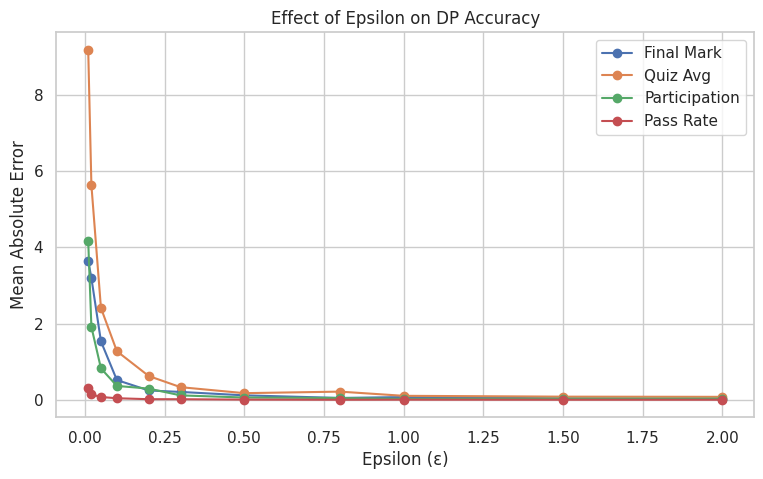

In [29]:
plt.figure(figsize=(9,5))

plt.plot(error_df["epsilon"], error_df["MAE_final"], marker="o", label="Final Mark")
plt.plot(error_df["epsilon"], error_df["MAE_quiz"], marker="o", label="Quiz Avg")
plt.plot(error_df["epsilon"], error_df["MAE_participation"], marker="o", label="Participation")
plt.plot(error_df["epsilon"], error_df["MAE_pass_rate"], marker="o", label="Pass Rate")

plt.title("Effect of Epsilon on DP Accuracy")
plt.xlabel("Epsilon (ε)")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()

### **Interpretation**
1- Very low ε (≈ 0.01 – 0.1)
- Errors are very high especially for Quiz Avg and Final Mark
- The noise added is strong which made the results almost heavily distorted.
- This is maximum privacy, minimum accuracy.

2- Low to medium ε (≈ 0.1 – 0.5)
- Error drops very fast for all metrics.
- privacy and accuracy start balancing out
- Still some noise but results start becoming usable.

3-  Medium to high ε (≈ 0.5 – 1.0)
- Errors become very small and stable.
- Most metrics are already close to true values.
- Noticeable balance between privacy and utility

4- High ε (≈ 1.0 – 2.0)
- Error is almost zero or negligible.
- Increasing ε further doesn’t change much.
- Privacy is weaker but accuracy is nearly perfect.


So practically, the optimale** epsilon value** is around 0.3 to 1, where we get reasonable privacy with strong utility , we can balance between privacy and accuracy

# **17. Utility Evaluation :**

In this section, we evaluate how useful the differentially private results are compared to the true statistics.

The main question is:

**After adding noise for privacy, are the results still accurate enough to be useful?  How much do we damage the data when we protect privacy?**


Differential privacy protects data by adding noise. However this noise changes the results.

So we must measure:
-  How far the noisy results are from the real values
- How accuracy changes as $\epsilon$ changes  
- Whether the results remain reliable for analysis  


We compare true vs noisy values for the previous queries:

To measure the difference between true and noisy results, we use three standard metrics:

#### 1. Mean Absolute Error (MAE)

$$
\text{MAE} = \frac{1}{n} \sum \left| y_{\text{true}} - y_{\text{private}} \right|
$$


#### 2. Root Mean Squared Error (RMSE)

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum \left( y_{\text{true}} - y_{\text{private}} \right)^2}
$$

#### 3. Relative Error (%)

$$
\text{Relative Error} = \frac{\left| y_{\text{true}} - y_{\text{private}} \right|}{\left| y_{\text{true}} \right|} \times 100
$$


In [30]:
def mae(true, pred):
    return abs(true - pred)

def rmse(true, pred):
    return ((true - pred) ** 2) ** 0.5

def relative_error(true, pred):
    if true == 0:
        return 0
    return abs(true - pred) / abs(true) * 100

We Compute utility per epsilon and aggregate results from previous experiments

In [31]:
utility_results = []

for eps in epsilons:
    subset = results_df[results_df["epsilon"] == eps]

    for col in ["final_mark", "quiz_avg", "participation", "pass_rate"]:

        true_val = true_values[col]
        preds = subset[col]

        utility_results.append({
            "epsilon": eps,
            "query": col,
            "MAE": abs(preds - true_val).mean(),
            "RMSE": ((preds - true_val) ** 2).mean() ** 0.5,
            "Relative_Error": (abs(preds - true_val) / abs(true_val)).mean() * 100
        })

utility_df = pd.DataFrame(utility_results)

utility_df.head()

,epsilon,query,MAE,RMSE,Relative_Error
0,0.01,final_mark,3.645854,5.330637,28.629303
1,0.01,quiz_avg,9.181464,10.380149,76.740863
2,0.01,participation,4.167014,5.629868,29.236048
3,0.01,pass_rate,0.314287,0.406663,35.528093
4,0.02,final_mark,3.194876,3.923064,25.087972


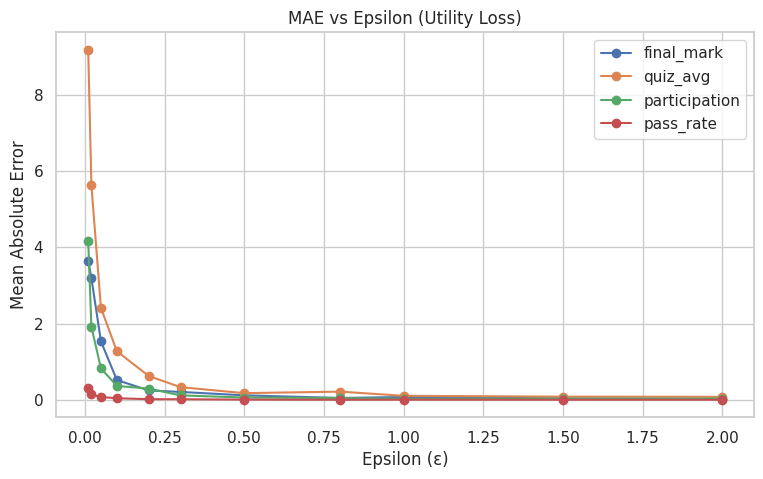

In [32]:
plt.figure(figsize=(9,5))

for col in utility_df["query"].unique():
    subset = utility_df[utility_df["query"] == col]
    plt.plot(subset["epsilon"], subset["MAE"], marker="o", label=col)

plt.title("MAE vs Epsilon (Utility Loss)")
plt.xlabel("Epsilon (ε)")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()

## **18. Mechanism Comparison: Laplace vs Gaussian :**

In this section, we compare the two differential privacy mechanisms used in this project:

- Laplace Mechanism  
- Gaussian Mechanism  

The goal is to understand:

**Which mechanism provides better accuracy while still preserving privacy?**

Both mechanisms add noise, but in different ways:

- **Laplace** : sharper noise and stronger ($\epsilon$-DP) guarantees  
- **Gaussian** : smoother noise and allows small probability of error (($\epsilon, \delta$)-DP)  

Even with the same $\epsilon$, the impact on results can differ.

So we compare them based on:

- Accuracy (error)  
- Stability (variation)  
- Behavior across $\epsilon$ values  


We apply both mechanisms to the same queries:

- Mean Final Mark  
- Mean Quiz Average  
- Mean Participation Average  

Then we measure:

- Mean Absolute Error (MAE)  
-  RMSE  

So for each $\epsilon$:

1. Run Laplace mechanism  
2. Run Gaussian mechanism  
3. Repeat multiple times (10 runs)  
4. Compute average error  



In [33]:
comparison_results = []

for eps in epsilons:
    for _ in range(10):

        comparison_results.append({
            "epsilon": eps,

            # Laplace
            "final_laplace": noisy_mean_final(df, eps, "laplace"),
            "quiz_laplace": noisy_mean_quiz(df, eps, "laplace"),
            "part_laplace": noisy_mean_participation(df, eps, "laplace"),

            # Gaussian
            "final_gaussian": noisy_mean_final(df, eps, "gaussian"),
            "quiz_gaussian": noisy_mean_quiz(df, eps, "gaussian"),
            "part_gaussian": noisy_mean_participation(df, eps, "gaussian"),
        })

In [34]:
comp_df = pd.DataFrame(comparison_results)

comp_df.head()

,epsilon,final_laplace,quiz_laplace,part_laplace,final_gaussian,quiz_gaussian,part_gaussian
0,0.01,26.733103,16.601322,13.924389,-29.904027,23.578455,11.549113
1,0.01,10.631808,12.524096,7.666836,-27.034009,17.026991,46.416491
2,0.01,9.829661,14.984510,15.884876,34.510075,33.839352,26.257375
3,0.01,20.714158,4.616309,3.841092,8.851923,29.436380,6.209848
4,0.01,34.973258,8.291352,14.991042,22.740193,10.684120,18.978257


In [35]:
comparison_error = []

for eps in epsilons:
    subset = comp_df[comp_df["epsilon"] == eps]

    comparison_error.append({
        "epsilon": eps,

        # Final mark
        "laplace_final": abs(subset["final_laplace"] - true_values["final_mark"]).mean(),
        "gaussian_final": abs(subset["final_gaussian"] - true_values["final_mark"]).mean(),

        # Quiz
        "laplace_quiz": abs(subset["quiz_laplace"] - true_values["quiz_avg"]).mean(),
        "gaussian_quiz": abs(subset["quiz_gaussian"] - true_values["quiz_avg"]).mean(),

        # Participation
        "laplace_part": abs(subset["part_laplace"] - true_values["participation"]).mean(),
        "gaussian_part": abs(subset["part_gaussian"] - true_values["participation"]).mean(),
    })

comparison_df = pd.DataFrame(comparison_error)

comparison_df

,epsilon,laplace_final,gaussian_final,laplace_quiz,gaussian_quiz,laplace_part,gaussian_part
0,0.01,5.839216,16.101649,3.380067,11.263881,3.751236,13.780042
1,0.02,3.361761,14.801918,1.738209,6.828162,1.888917,6.113425
2,0.05,1.142279,3.544087,0.509706,2.626279,0.736125,1.914025
3,0.10,0.401189,2.113217,0.317179,1.370972,0.249627,1.124161
4,0.20,0.392364,1.555616,0.144964,0.593485,0.174787,0.622326
5,0.30,0.291187,0.936640,0.103816,0.442353,0.066614,0.408080
6,0.50,0.104680,0.720030,0.033426,0.222701,0.075232,0.312034
7,0.80,0.074537,0.220300,0.021167,0.091999,0.050844,0.214304
8,1.00,0.031860,0.186690,0.039643,0.083845,0.044900,0.181551
9,1.50,0.027805,0.126617,0.012137,0.059859,0.027560,0.075010


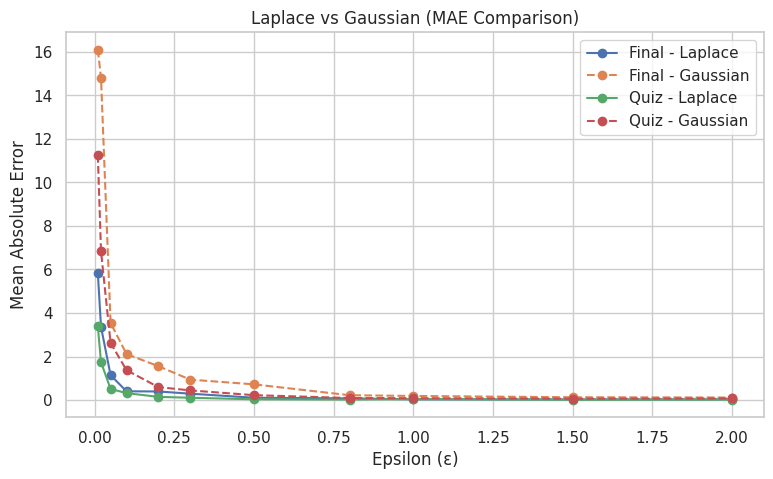

In [36]:
plt.figure(figsize=(9,5))

plt.plot(comparison_df["epsilon"], comparison_df["laplace_final"], marker="o", label="Final - Laplace")
plt.plot(comparison_df["epsilon"], comparison_df["gaussian_final"], marker="o", linestyle="--", label="Final - Gaussian")

plt.plot(comparison_df["epsilon"], comparison_df["laplace_quiz"], marker="o", label="Quiz - Laplace")
plt.plot(comparison_df["epsilon"], comparison_df["gaussian_quiz"], marker="o", linestyle="--", label="Quiz - Gaussian")

plt.title("Laplace vs Gaussian (MAE Comparison)")
plt.xlabel("Epsilon (ε)")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()

### **Interpretation :**

From the comparison:

- Laplace Mechanism : It provides strict privacy guarantees (ε-DP) and can produce larger variations (sharp noise) , Sometimes higher error
- Gaussian Mechanism :It produces smoother noise , it is often more stable for averages
### Observations:
- **For small ε:** Both mechanisms produce high error
- **For medium ε:** Gaussian often becomes more stable
- **For large ε:** Both converge toward true values

So both mechanisms are valid, but they behave differently:

**Laplace** is preferred for strict privacy guarantee and **Gaussian** is useful for smoother, more stable results

The choice depends on:

- required privacy level
- type of query
- acceptable level of error


This comparison shows that:

Differential privacy is **not only about ε** since the choice of mechanism also affects utility .

# **19. Group-Level Privacy Analysis :**


In this section, we extend our analysis from the whole dataset to groups of students.

Instead of computing global statistics, we analyze:

**How differential privacy behaves across different performance levels**


So far, we applied DP on the entire dataset.

However, in real scenarios, data is often analyzed by groups such as:

- Weak students  
- Average students  
- High performing students  

Analyzing groups helps us:

- Understand whether DP behaves differently on smaller subsets  
- Observe how group size affects noise and error  


We divide students into three groups based on their course mark:

- **Low** → $course\_mark < 10$  
- **Medium** → $10 \leq course\_mark < 14$  
- **High** → $course\_mark \geq 14$  

This creates meaningful performance categories.


For each group, we compute:

- Mean Final Mark (with DP)  
- Mean Quiz Average (with DP)  
- Pass Rate (with DP)  

Then we compare:

- True values vs noisy values  
- Behavior across groups  

Groups are smaller than the full dataset.

This means:

- Sensitivity becomes higher (because $n$ is smaller)  
- Noise impact increases  
- Accuracy may decrease  



Create performance groups

In [37]:
def assign_group(mark):
    if mark < 10:
        return "Low"
    elif mark < 14:
        return "Medium"
    else:
        return "High"

df["performance_group"] = df["course_mark"].apply(assign_group)

df["performance_group"].value_counts()

,count
performance_group,
Medium,186
High,45
Low,29


True statistics per group

In [38]:
group_true = df.groupby("performance_group").agg({
    "final_mark": "mean",
    "quiz_avg": "mean",
    "passed": "mean"
}).reset_index()

group_true

,performance_group,final_mark,quiz_avg,passed
0,High,15.965111,13.078667,0.977778
1,Low,8.125172,11.044368,0.000000
2,Medium,12.671828,11.838047,1.000000


Apply differential privacy on each group

In [39]:
epsilon_group = 0.5

group_dp_results = []

for group in df["performance_group"].unique():

    subset = df[df["performance_group"] == group]

    for _ in range(10):  # repeat for stability

        group_dp_results.append({
            "group": group,
            "final_noisy": noisy_mean_final(subset, epsilon_group, "laplace"),
            "quiz_noisy": noisy_mean_quiz(subset, epsilon_group, "gaussian"),
            "pass_noisy": noisy_pass_rate(subset, epsilon_group, "laplace")
        })

In [40]:
group_dp_df = pd.DataFrame(group_dp_results)

group_dp_df.head()

,group,final_noisy,quiz_noisy,pass_noisy
0,Medium,12.560419,11.531229,1.001925
1,Medium,12.596238,11.832129,1.009722
2,Medium,12.613681,11.723368,0.979228
3,Medium,12.642309,11.827532,0.999560
4,Medium,12.699043,12.261941,1.013697


Compute average noisy values per group

In [41]:
group_noisy_avg = group_dp_df.groupby("group").mean().reset_index()

group_noisy_avg

,group,final_noisy,quiz_noisy,pass_noisy
0,High,16.355118,13.100687,0.999017
1,Low,7.941243,11.857267,-0.036477
2,Medium,12.639383,11.859267,0.997389


Compare true vs noisy

In [42]:
comparison_group = group_true.merge(group_noisy_avg, left_on="performance_group", right_on="group")

comparison_group

,performance_group,final_mark,quiz_avg,passed,group,final_noisy,quiz_noisy,pass_noisy
0,High,15.965111,13.078667,0.977778,High,16.355118,13.100687,0.999017
1,Low,8.125172,11.044368,0.000000,Low,7.941243,11.857267,-0.036477
2,Medium,12.671828,11.838047,1.000000,Medium,12.639383,11.859267,0.997389


Visualization

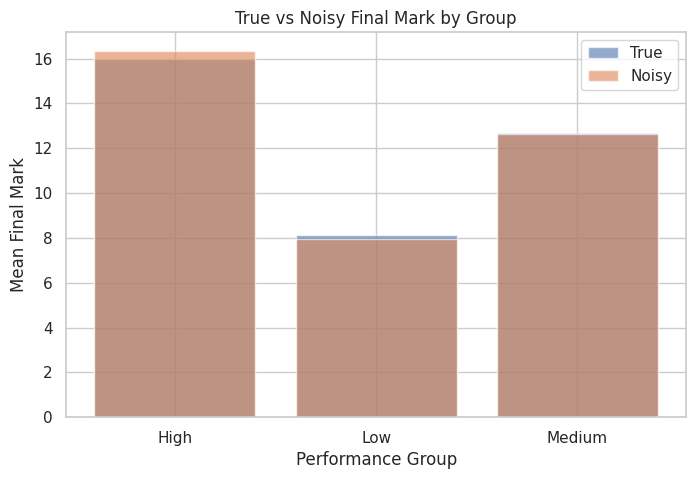

In [43]:
plt.figure(figsize=(8,5))

plt.bar(comparison_group["performance_group"], comparison_group["final_mark"], alpha=0.6, label="True")
plt.bar(comparison_group["performance_group"], comparison_group["final_noisy"], alpha=0.6, label="Noisy")

plt.title("True vs Noisy Final Mark by Group")
plt.xlabel("Performance Group")
plt.ylabel("Mean Final Mark")
plt.legend()
plt.show()

# **Visualizations :**

In this section, we visualize the results of differential privacy experiments to better understand:

- How error changes with $\epsilon$  
- How noisy values compare to true values  
- Differences between Laplace and Gaussian mechanisms  
- Behavior of noise  
- Impact on different student groups  

Visualization makes the analysis clearer and highlights patterns that are not obvious from tables.

- It includes :

- MAE vs $\epsilon$  
- True vs Noisy comparisons
- True vs Noisy curves  
- Laplace vs Gaussian comparison  
- Noise distributions  
- Group-level comparisons  
- Relative error plots  
- Error heatmap  

### MAE vs Epsilon :
Shows how error decreases as ε increases.

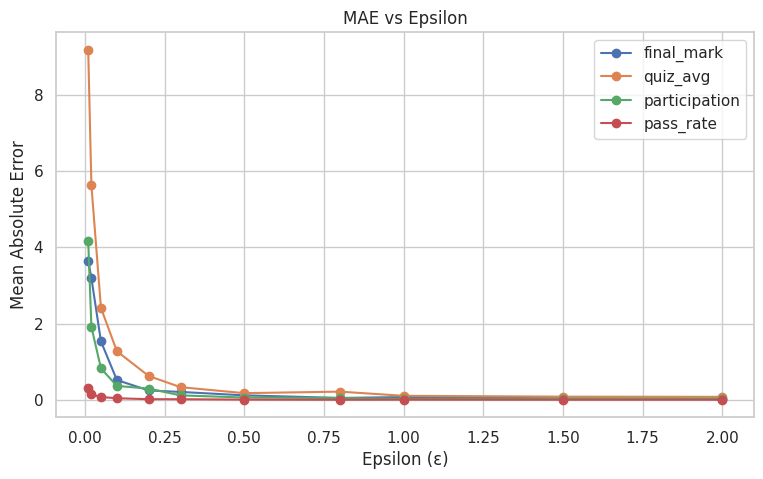

In [44]:
plt.figure(figsize=(9,5))

for col in utility_df["query"].unique():
    subset = utility_df[utility_df["query"] == col]
    plt.plot(subset["epsilon"], subset["MAE"], marker="o", label=col)

plt.title("MAE vs Epsilon")
plt.xlabel("Epsilon (ε)")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()

### True vs Noisy :
Compare true and noisy values directly.

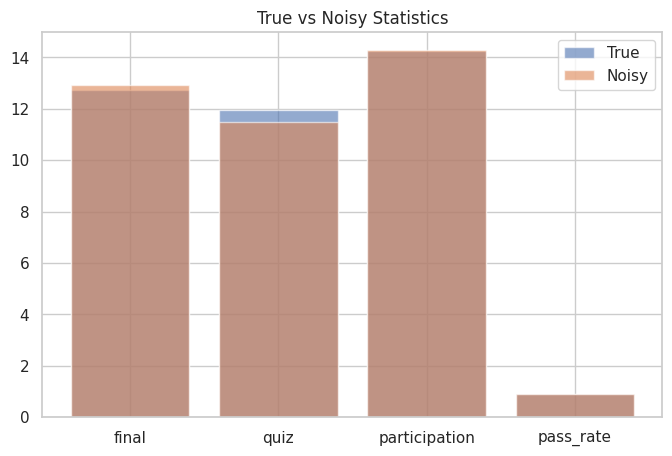

In [45]:
epsilon_demo = 0.5

true_vals = {
    "final": df["final_mark"].mean(),
    "quiz": df["quiz_avg"].mean(),
    "participation": df["participation_avg"].mean(),
    "pass_rate": df["passed"].mean()
}

noisy_vals = {
    "final": noisy_mean_final(df, epsilon_demo),
    "quiz": noisy_mean_quiz(df, epsilon_demo, "gaussian"),
    "participation": noisy_mean_participation(df, epsilon_demo),
    "pass_rate": noisy_pass_rate(df, epsilon_demo)
}

labels = list(true_vals.keys())

plt.figure(figsize=(8,5))
plt.bar(labels, true_vals.values(), alpha=0.6, label="True")
plt.bar(labels, noisy_vals.values(), alpha=0.6, label="Noisy")

plt.title("True vs Noisy Statistics")
plt.legend()
plt.show()

### True vs Noisy :
Compare distributions

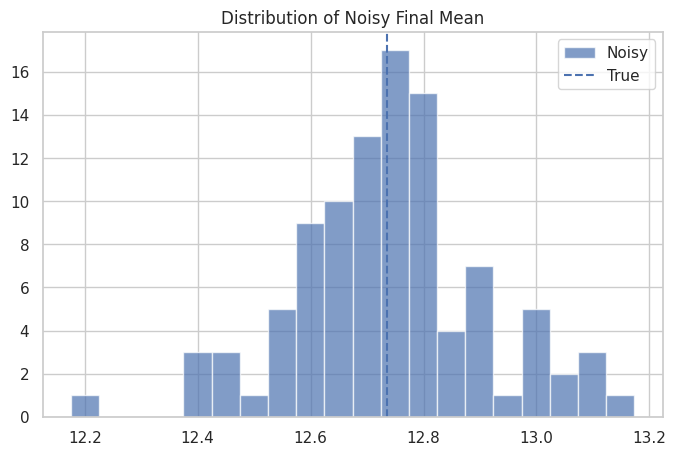

In [46]:
epsilon_demo = 0.5

noisy_samples = [noisy_mean_final(df, epsilon_demo) for _ in range(100)]

plt.figure(figsize=(8,5))
plt.hist(noisy_samples, bins=20, alpha=0.7, label="Noisy")
plt.axvline(df["final_mark"].mean(), linestyle="--", label="True")

plt.title("Distribution of Noisy Final Mean")
plt.legend()
plt.show()

### True vs Noisy Curves

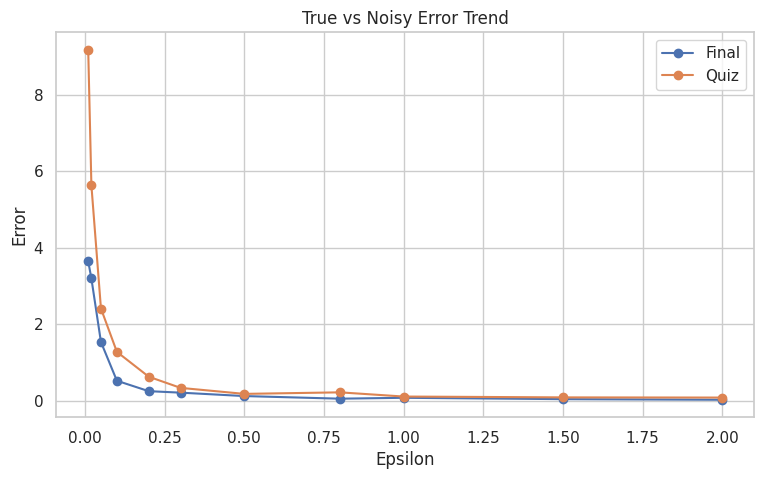

In [47]:
plt.figure(figsize=(9,5))

plt.plot(error_df["epsilon"], error_df["MAE_final"], marker="o", label="Final")
plt.plot(error_df["epsilon"], error_df["MAE_quiz"], marker="o", label="Quiz")

plt.title("True vs Noisy Error Trend")
plt.xlabel("Epsilon")
plt.ylabel("Error")
plt.legend()
plt.show()

### Laplace vs Gaussian comparison

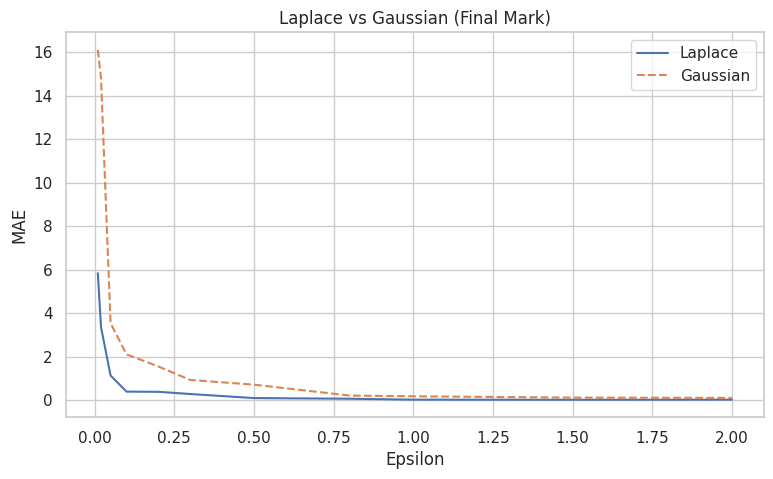

In [48]:
plt.figure(figsize=(9,5))

plt.plot(comparison_df["epsilon"], comparison_df["laplace_final"], label="Laplace")
plt.plot(comparison_df["epsilon"], comparison_df["gaussian_final"], linestyle="--", label="Gaussian")

plt.title("Laplace vs Gaussian (Final Mark)")
plt.xlabel("Epsilon")
plt.ylabel("MAE")
plt.legend()
plt.show()

### Noise Distibution

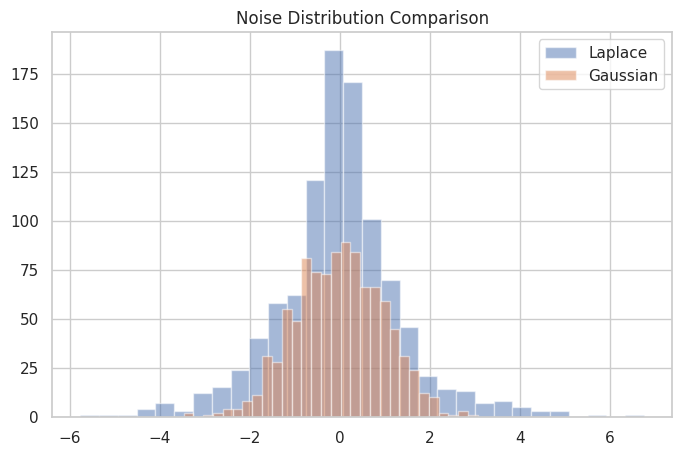

In [49]:
laplace_noise = [np.random.laplace(0, 1) for _ in range(1000)]
gaussian_noise = [np.random.normal(0, 1) for _ in range(1000)]

plt.figure(figsize=(8,5))
plt.hist(laplace_noise, bins=30, alpha=0.5, label="Laplace")
plt.hist(gaussian_noise, bins=30, alpha=0.5, label="Gaussian")

plt.title("Noise Distribution Comparison")
plt.legend()
plt.show()

### Group Level Comparison

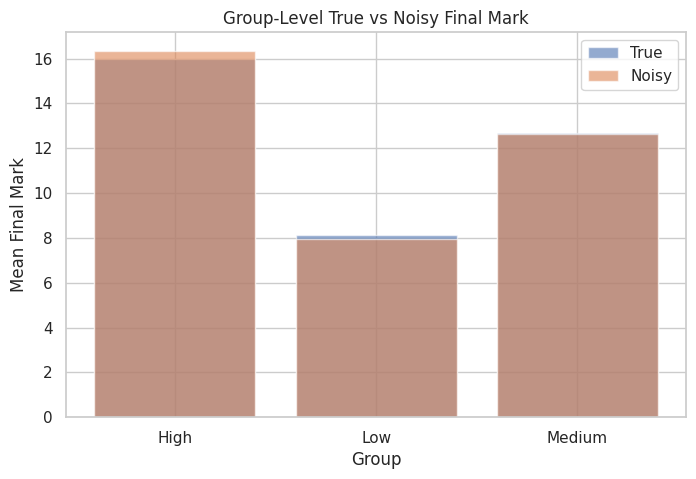

In [50]:
plt.figure(figsize=(8,5))

plt.bar(comparison_group["performance_group"], comparison_group["final_mark"], alpha=0.6, label="True")
plt.bar(comparison_group["performance_group"], comparison_group["final_noisy"], alpha=0.6, label="Noisy")

plt.title("Group-Level True vs Noisy Final Mark")
plt.xlabel("Group")
plt.ylabel("Mean Final Mark")
plt.legend()
plt.show()

### Relative Error Plot

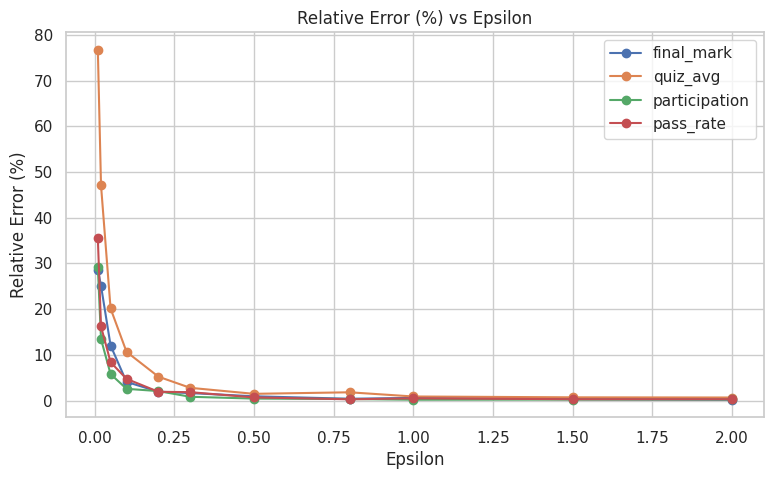

In [51]:
plt.figure(figsize=(9,5))

for col in utility_df["query"].unique():
    subset = utility_df[utility_df["query"] == col]
    plt.plot(subset["epsilon"], subset["Relative_Error"], marker="o", label=col)

plt.title("Relative Error (%) vs Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Relative Error (%)")
plt.legend()
plt.show()

### Error Heatmap

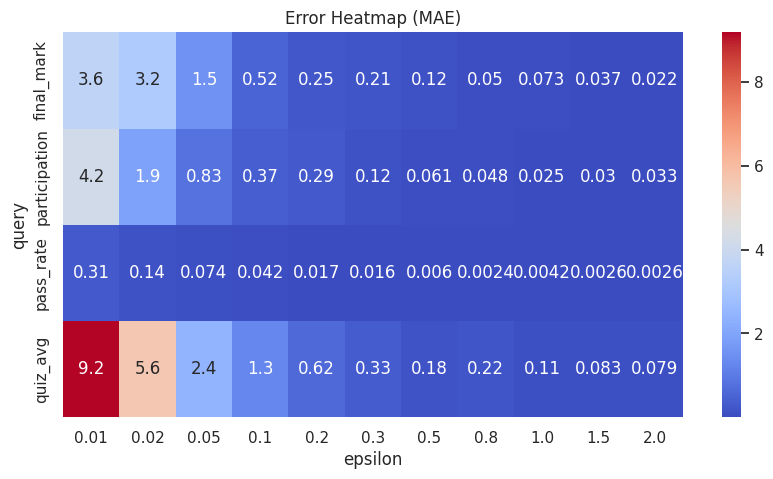

In [52]:
pivot = utility_df.pivot(index="query", columns="epsilon", values="MAE")

plt.figure(figsize=(10,5))
sns.heatmap(pivot, annot=True, cmap="coolwarm")

plt.title("Error Heatmap (MAE)")
plt.show()

Visualization confirms the core idea of **differential privacy:**
- It protects individual data while still allowing useful analysis, but always introduces a **trade off** between privacy and accuracy

## **21. Robustness Analysis :**


In this section, we evaluate how differential privacy behaves under different dataset sizes.

The main question is:

**Does differential privacy perform better on large datasets compared to small ones?**

From previous sections, we observed that:

- Noise depends on sensitivity  
- Sensitivity depends on dataset size  

So we expect:

- Smaller datasets : higher impact of noise  
- Larger datasets : more stable results  

This section tests that idea experimentally.


We simulate different dataset sizes by creating subsets:

- Small dataset of 50 students  
- Medium dataset of 150 students  
- Full dataset of 260 students  

Then we:

- Apply the same DP queries  
- Use the same $\epsilon$  
- Compare errors  


For each dataset size we :

- Compute noisy results  
- Compare with true values  
- Compute MAE  

This shows how utility changes with dataset size.

In [53]:
df_small = df.sample(n=50, random_state=42)
df_medium = df.sample(n=150, random_state=42)
df_full = df.copy()

In [54]:
epsilon_test = 0.5

In [55]:
def compute_mae_for_dataset(data, epsilon):

    true_final = data["final_mark"].mean()

    noisy_vals = [noisy_mean_final(data, epsilon) for _ in range(10)]

    mae = np.mean([abs(v - true_final) for v in noisy_vals])

    return mae

Run robustness test

In [56]:
results = []

datasets = {
    "Small (50)": df_small,
    "Medium (150)": df_medium,
    "Full (260)": df_full
}

for name, data in datasets.items():
    mae = compute_mae_for_dataset(data, epsilon_test)

    results.append({
        "dataset": name,
        "MAE": mae
    })

robust_df = pd.DataFrame(results)

robust_df

,dataset,MAE
0,Small (50),0.374045
1,Medium (150),0.271998
2,Full (260),0.082320


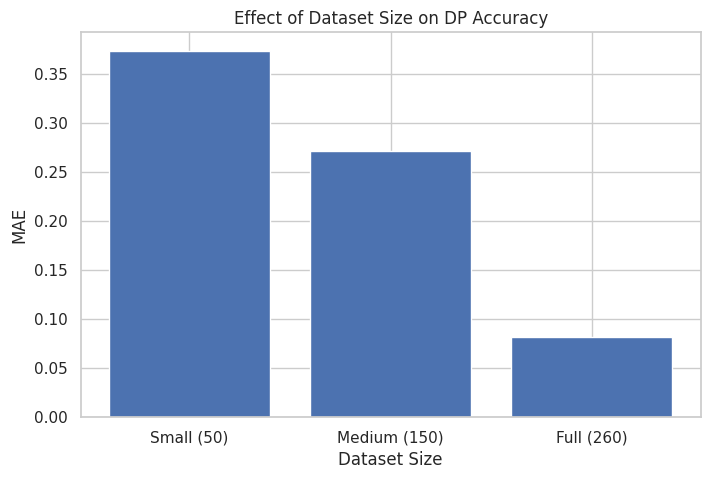

In [57]:
plt.figure(figsize=(8,5))

plt.bar(robust_df["dataset"], robust_df["MAE"])

plt.title("Effect of Dataset Size on DP Accuracy")
plt.xlabel("Dataset Size")
plt.ylabel("MAE")
plt.show()

### Interpretation

From the results:

1- Small dataset (50 students):
- highest error
- strong noise impact

2- Medium dataset (150 students):
- moderate error

3- Full dataset (260 students):
- lowest error
- most stable results

### -  Insights :

Differential privacy becomes more accurate as dataset size increases.

This happens because:
- sensitivity decreases with larger n
- noise becomes smaller relative to the data

# **22. Simulated Privacy Attack :**


In this section, we simulate a simple privacy attack to understand why differential privacy is needed.

The goal is to show:

**What could an attacker infer from the data without DP, and what changes when DP is applied?**

Up to now, we showed:

- DP adds noise  
- DP protects data  
- DP reduces accuracy slightly  

But we still need to answer a deeper question: **What exactly is being protected?**

This section demonstrates that **individual level information** can be indirectly inferred from aggregate data.


We simulate a situation where an attacker:

- Knows most of the dataset  
- Removes one student  
- Recomputes a statistic (like mean or pass rate)  
- Compares results  

If the difference is noticeable then the attacker can learn something about that missing student.

We will compare:

-  **Without DP** : exact recomputation reveals sensitive change  
-  **With DP** : noise hides the contribution of one individual  
  
- All of that to check whether one individual's data affects the output  

In [58]:
true_full_mean = df["final_mark"].mean()

print("True mean (full dataset):", true_full_mean)

True mean (full dataset): 12.73469230769231


Remove one student (simulated attacker knowledge)

In [59]:
df_removed = df.drop(index=0)  # simulate removing one student

removed_mean = df_removed["final_mark"].mean()

print("Mean after removing one student:", removed_mean)

Mean after removing one student: 12.735173745173746


Measure sensitivity effect

In [60]:
difference = abs(true_full_mean - removed_mean)

print("Difference caused by one student:", difference)

Difference caused by one student: 0.00048143748143658627


Apply Differential Privacy

In [61]:
dp_mean_full = noisy_mean_final(df, epsilon=0.5)
dp_mean_removed = noisy_mean_final(df_removed, epsilon=0.5)

print("DP full mean:", dp_mean_full)
print("DP removed mean:", dp_mean_removed)
print("DP difference:", abs(dp_mean_full - dp_mean_removed))

DP full mean: 12.66783508196856
DP removed mean: 12.733414495026931
DP difference: 0.06557941305837112


### Interpretation
**1. Without DP (True data)**

Difference = 0.00048 (very tiny)

This difference comes from:

- real data change only

When we remove one student:

- the **dataset** actually changes and the **mean** changes slightly and
everything is deterministic (no randomness) , which means :

This is the true sensitivity of the dataset , so it's : small , stable , predicteed and purely caused by one student

**2. With DP (Noisy data)**

Difference = 0.0656 (much larger)

But here something important happens:

This difference is NOT only from removing the student

It comes from:

- removing one student (real effect)
- adding random noise in both outputs (DP effect)

So each mean is “shifted” randomly , which makes the difference umpredictable and random , with DP, **the difference** becomes random and unpredictable because **noise** is added independently to each query result.

## **23. Interpretation and Insights :**


In this section, we summarize everything learned from the experiments by analyzing how $\epsilon$ affects:

- Privacy   
- Accuracy
- Stability  

The goal is to extract clear conclusions from all previous steps and identify the best operating region for $\epsilon$.


We focus on three main questions:

- Which $\epsilon$ values give the best balance between privacy and accuracy?  
- How does error change when $\epsilon$ increases?  
- What trade-offs do we observe in real results?  

We already found from previous results that :

- Small $\epsilon$ : strong privacy, low accuracy  
- Large $\epsilon$ :  weak privacy, high accuracy  
- Medium $\epsilon$ : best trade-off region  


We combine results into a single table containing:

- $\epsilon$ values  
- MAE (error)  
- Relative error  
- Interpretation level  


In [62]:
summary_table = error_df.copy()

summary_table

,epsilon,MAE_final,MAE_quiz,MAE_participation,MAE_pass_rate
0,0.01,3.645854,9.181464,4.167014,0.314287
1,0.02,3.194876,5.631918,1.914756,0.143382
2,0.05,1.532831,2.409252,0.825208,0.074176
3,0.10,0.518966,1.275019,0.365083,0.041974
4,0.20,0.246096,0.624459,0.294553,0.016949
5,0.30,0.207364,0.332176,0.116915,0.016159
6,0.50,0.118005,0.175209,0.060538,0.006003
7,0.80,0.049612,0.215352,0.047671,0.002387
8,1.00,0.072784,0.105594,0.025207,0.004209
9,1.50,0.037408,0.083480,0.029833,0.002599


In [63]:
def privacy_level(eps):
    if eps <= 0.1:
        return "Strong Privacy"
    elif eps <= 0.8:
        return "Balanced"
    else:
        return "Low Privacy"

summary_table["privacy_level"] = summary_table["epsilon"].apply(privacy_level)

summary_table

,epsilon,MAE_final,MAE_quiz,MAE_participation,MAE_pass_rate,privacy_level
0,0.01,3.645854,9.181464,4.167014,0.314287,Strong Privacy
1,0.02,3.194876,5.631918,1.914756,0.143382,Strong Privacy
2,0.05,1.532831,2.409252,0.825208,0.074176,Strong Privacy
3,0.10,0.518966,1.275019,0.365083,0.041974,Strong Privacy
4,0.20,0.246096,0.624459,0.294553,0.016949,Balanced
5,0.30,0.207364,0.332176,0.116915,0.016159,Balanced
6,0.50,0.118005,0.175209,0.060538,0.006003,Balanced
7,0.80,0.049612,0.215352,0.047671,0.002387,Balanced
8,1.00,0.072784,0.105594,0.025207,0.004209,Low Privacy
9,1.50,0.037408,0.083480,0.029833,0.002599,Low Privacy


We define a simple utility score:

**Higher score = better accuracy**

In [64]:
summary_table["utility_score"] = 1 / (summary_table["MAE_final"] + 1e-6)

summary_table

,epsilon,MAE_final,MAE_quiz,MAE_participation,MAE_pass_rate,privacy_level,utility_score
0,0.01,3.645854,9.181464,4.167014,0.314287,Strong Privacy,0.274284
1,0.02,3.194876,5.631918,1.914756,0.143382,Strong Privacy,0.313001
2,0.05,1.532831,2.409252,0.825208,0.074176,Strong Privacy,0.652387
3,0.10,0.518966,1.275019,0.365083,0.041974,Strong Privacy,1.926904
4,0.20,0.246096,0.624459,0.294553,0.016949,Balanced,4.063444
5,0.30,0.207364,0.332176,0.116915,0.016159,Balanced,4.822426
6,0.50,0.118005,0.175209,0.060538,0.006003,Balanced,8.474116
7,0.80,0.049612,0.215352,0.047671,0.002387,Balanced,20.156032
8,1.00,0.072784,0.105594,0.025207,0.004209,Low Privacy,13.739133
9,1.50,0.037408,0.083480,0.029833,0.002599,Low Privacy,26.731724


Best ε values , we filter by :

- error is low enough , while :
- privacy is not too weak and there is a balance between accuracy and privacy

In [65]:
balanced_eps = summary_table[
    (summary_table["MAE_final"] < 0.5) &
    (summary_table["epsilon"] <= 1.0)
]

balanced_eps

,epsilon,MAE_final,MAE_quiz,MAE_participation,MAE_pass_rate,privacy_level,utility_score
4,0.2,0.246096,0.624459,0.294553,0.016949,Balanced,4.063444
5,0.3,0.207364,0.332176,0.116915,0.016159,Balanced,4.822426
6,0.5,0.118005,0.175209,0.060538,0.006003,Balanced,8.474116
7,0.8,0.049612,0.215352,0.047671,0.002387,Balanced,20.156032
8,1.0,0.072784,0.105594,0.025207,0.004209,Low Privacy,13.739133


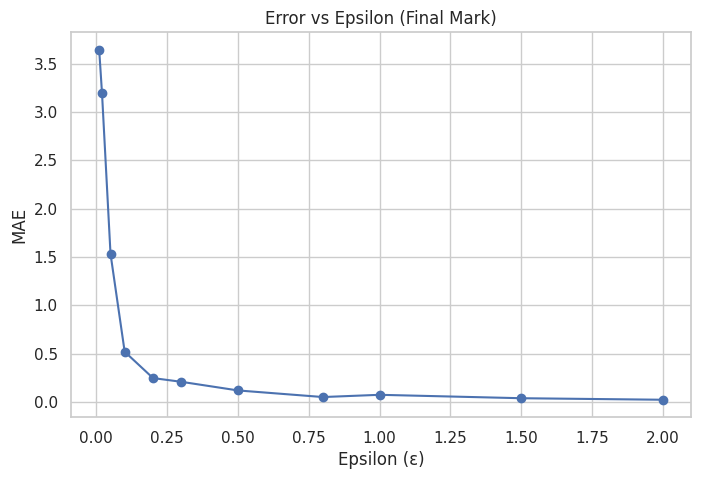

In [66]:
plt.figure(figsize=(8,5))

plt.plot(summary_table["epsilon"], summary_table["MAE_final"], marker="o")
plt.title("Error vs Epsilon (Final Mark)")
plt.xlabel("Epsilon (ε)")
plt.ylabel("MAE")
plt.show()

In [67]:
summary_table[["epsilon", "MAE_final", "MAE_quiz", "MAE_participation", "MAE_pass_rate", "privacy_level"]]

,epsilon,MAE_final,MAE_quiz,MAE_participation,MAE_pass_rate,privacy_level
0,0.01,3.645854,9.181464,4.167014,0.314287,Strong Privacy
1,0.02,3.194876,5.631918,1.914756,0.143382,Strong Privacy
2,0.05,1.532831,2.409252,0.825208,0.074176,Strong Privacy
3,0.10,0.518966,1.275019,0.365083,0.041974,Strong Privacy
4,0.20,0.246096,0.624459,0.294553,0.016949,Balanced
5,0.30,0.207364,0.332176,0.116915,0.016159,Balanced
6,0.50,0.118005,0.175209,0.060538,0.006003,Balanced
7,0.80,0.049612,0.215352,0.047671,0.002387,Balanced
8,1.00,0.072784,0.105594,0.025207,0.004209,Low Privacy
9,1.50,0.037408,0.083480,0.029833,0.002599,Low Privacy


### Interpretation of Results
1. Best ε values

From the table:

Best **accuracy** usually appears at **higher ε values** (1.0 – 2.0) but these values provide **weaker privacy**

So **best value** depends on goal:

- privacy focused : small ε
- accuracy-focused  : large ε
- balanced : middle ε
 2. Trade-off observed

We clearly see:

As **ε increases** the error decreases and as **ε decreases** the privacy increases

So there is a direct trade-off:

We cannot maximize privacy and accuracy at the same time

3. Important observations

**Small ε (0.01 – 0.1)**
- very strong privacy
- very noisy results
- high error

**Medium ε (0.3 – 0.8)**

- balanced performance
- acceptable accuracy
- recommended region for optimal epsilon value

**Large ε (1.0 – 2.0)**
- low noise
- high accuracy
- weak privacy protection

# **24. Final Trade-off Table :**


In this section, we build a final table that summarizes the **privacy and accuracy trade-off** for all queries and $\epsilon$ values.

This table answers the core question of the project:

What is the best configuration of $\epsilon$ that balances privacy and utility?

Up to now, we have:

- Computed noisy statistics  
- Measured errors (MAE, RMSE, Relative Error)  
- Analyzed different $\epsilon$ values  

Now we will combine everything into one clear decision table.



For each $\epsilon$, we include:

- Query name  
- $\epsilon$ (privacy budget)  
- MAE (accuracy loss)  
- RMSE (error stability)  
- Relative Error (%)  
- Privacy Level  
- Trade-off Score  

Based on last results and plots we can clearly define :

- $\epsilon \leq 0.1$ : Strong Privacy  
- $0.1 < \epsilon \leq 1.0$ : Balanced  
- $\epsilon > 1.0$ : Low Privacy  

In [68]:
final_table = utility_df.copy()

final_table.head()

,epsilon,query,MAE,RMSE,Relative_Error
0,0.01,final_mark,3.645854,5.330637,28.629303
1,0.01,quiz_avg,9.181464,10.380149,76.740863
2,0.01,participation,4.167014,5.629868,29.236048
3,0.01,pass_rate,0.314287,0.406663,35.528093
4,0.02,final_mark,3.194876,3.923064,25.087972


In [69]:
def classify_privacy(eps):
    if eps <= 0.1:
        return "Strong"
    elif eps <= 1.0:
        return "Balanced"
    else:
        return "Low"

final_table["privacy_level"] = final_table["epsilon"].apply(classify_privacy)

We normalize error to combine it fairly with ε

In [70]:
final_table["norm_MAE"] = final_table["MAE"] / final_table["MAE"].max()
final_table["norm_epsilon"] = final_table["epsilon"] / final_table["epsilon"].max()

We balance privacy and utility:

In [71]:
final_table["tradeoff_score"] = (
    0.5 * final_table["norm_MAE"] +
    0.5 * final_table["norm_epsilon"]
)

In [72]:
best_configs = final_table.sort_values("tradeoff_score").head(10)

best_configs

,epsilon,query,MAE,RMSE,Relative_Error,privacy_level,norm_MAE,norm_epsilon,tradeoff_score
7,0.02,pass_rate,0.143382,0.171983,16.208350,Strong,0.015616,0.010,0.012808
11,0.05,pass_rate,0.074176,0.093927,8.385083,Strong,0.008079,0.025,0.016539
3,0.01,pass_rate,0.314287,0.406663,35.528093,Strong,0.034231,0.005,0.019615
15,0.10,pass_rate,0.041974,0.051933,4.744871,Strong,0.004572,0.050,0.027286
14,0.10,participation,0.365083,0.549765,2.561447,Strong,0.039763,0.050,0.044882
19,0.20,pass_rate,0.016949,0.019478,1.915927,Balanced,0.001846,0.100,0.050923
12,0.10,final_mark,0.518966,0.648221,4.075216,Strong,0.056523,0.050,0.053262
10,0.05,participation,0.825208,0.902582,5.789714,Strong,0.089878,0.025,0.057439
16,0.20,final_mark,0.246096,0.292630,1.932482,Balanced,0.026804,0.100,0.063402
18,0.20,participation,0.294553,0.388909,2.066604,Balanced,0.032081,0.100,0.066041


In [73]:
final_table[[
    "query",
    "epsilon",
    "MAE",
    "RMSE",
    "Relative_Error",
    "privacy_level",
    "tradeoff_score"
]]

,query,epsilon,MAE,RMSE,Relative_Error,privacy_level,tradeoff_score
0,final_mark,0.01,3.645854,5.330637,28.629303,Strong,0.201044
1,quiz_avg,0.01,9.181464,10.380149,76.740863,Strong,0.502500
2,participation,0.01,4.167014,5.629868,29.236048,Strong,0.229425
3,pass_rate,0.01,0.314287,0.406663,35.528093,Strong,0.019615
4,final_mark,0.02,3.194876,3.923064,25.087972,Strong,0.178985
5,quiz_avg,0.02,5.631918,6.374751,47.072913,Strong,0.311700
6,participation,0.02,1.914756,2.305061,13.434059,Strong,0.109273
7,pass_rate,0.02,0.143382,0.171983,16.208350,Strong,0.012808
8,final_mark,0.05,1.532831,2.120875,12.036651,Strong,0.095974
9,quiz_avg,0.05,2.409252,3.244804,20.137106,Strong,0.143702


## Interpretation

### 1. Best $\epsilon$ values

From the table:

Best trade-off usually appears in:

$$
\epsilon \approx 0.3 \;-\; 0.8
$$

These values provide:

- Acceptable accuracy  
- Reasonable privacy protection  


###  2. Trade-off behavior

- **Low $\epsilon$**:  
  - Strong privacy  
  - High error  

- **High $\epsilon$**:  
  - Low error  
  - Weak privacy  

- **Medium $\epsilon$**:  
  - Best compromise where the balance between privacy and accuracy is achieved



###  3. Query differences

- **Pass rate** : lowest error (low sensitivity)  
- **Means** : higher error (continuous values)  

###  Conclusion

There is no single optimal $\epsilon$, but a **range of values** that provides a good balance between privacy and utility.


So , The best configuration depends on system goals:

- **Privacy-critical systems** when $\epsilon \leq 0.3$  
- **Balanced analytics** happens when $\epsilon \approx 0.3 - 0.8$  
- **High-accuracy reporting** happens when  $\epsilon \geq 1.0$  


**The optimal $\epsilon$ lies in the medium range, where both privacy protection and data utility are reasonably preserved.**



# **Project Summary**

In this project, we designed and implemented a **privacy-preserving student analytics system** using differential privacy.

The system computes useful statistics such as:

- Average grades  
- Participation levels  
- Pass rates  

while protecting the privacy of individual students by adding controlled noise.


We successfully:

- Analyzed a real student dataset  
- Implemented differential privacy mechanisms (Laplace and Gaussian)  
- Computed private versions of key statistics  
- Evaluated the impact of noise on accuracy  
- Studied the effect of $\epsilon$ on privacy and utility  
- Compared different mechanisms  
- Tested behavior on groups and different dataset sizes  
- Simulated a privacy attack to show the need for DP  


#### 1. Privacy–Utility Trade-off

We obsreved a  clear trade-off :

- Small $\epsilon$ : strong privacy but high error  
- Large $\epsilon$ : high accuracy but weak privacy  

This confirms the fundamental principle of differential privacy.


#### 2. Optimal $\epsilon$ Range

From experiments:

- $\epsilon$ between **0.3 and 0.8** provides the best balance  
- Very small $\epsilon$ produces unstable results  
- Very large $\epsilon$ reduces privacy significantly  


#### 3. Mechanism behavior

- Laplace mechanism provides strict privacy guarantees  
- Gaussian mechanism produces smoother and more stable results  
- Both converge to true values as $\epsilon$ increases  


#### 4. Effect of dataset size

- Larger datasets improve accuracy  
- Smaller datasets amplify noise  
- DP is more effective when more data is available  

#### 5. Group-level limitations

- Applying DP on small groups increases error  
- Results remain useful but less precise  
- Group size must be considered in practice  


#### 6. Protection against inference attacks

The simulated attack showed:

- Without DP the individual influence can be detected  
- With DP the noise hides individual contribution  

This demonstrates the practical value of differential privacy.

### Final answer to the problem

It is possible to share useful student performance statistics **without compromising individual privacy** by applying differential privacy mechanisms.

However, this comes with a necessary trade-off:

- Some accuracy is lost  
- But privacy is significantly improved  

This system can be used in:

- Educational dashboards  
- Institutional reporting  
- Analytics platforms  

where privacy protection is required.



### Final insight

Differential privacy is not about perfect accuracy, but about:

**providing useful insights while guaranteeing that no single individual can be identified.**

### Closing statement

This project demonstrates that **privacy and data analysis can coexist**, as long as the balance between them is carefully managed through an appropriate choice of $\epsilon$ and mechanism.